# 🏆 Hackathon CNN — Classification de la Leucémie
**⏱️ 4 heures | 🎯 Maximiser la Val Accuracy**

| Piste | Thème | Difficulté | Impact |
|-------|-------|------------|--------|
| 0 | ✅ Baseline | ⭐ | ~62% ( pourcentage à titre indicatif)|
| 1 | 📦 Data Augmentation | ⭐⭐ | +3-5% |
| 2 | 🏗️ Architecture | ⭐⭐ | +5-8% |
| 3 | ⚙️ Scheduler | ⭐⭐ | +3-6% |
| 4 | ⚖️ Déséquilibre | ⭐⭐⭐ | +5-10% |
| 5 | 🔬 Fine-tuning | ⭐⭐⭐ | +8-12% |
| 6 | 🧪 Tout combiner | ⭐⭐⭐⭐ | +15-20% |

# Loading Data & Setup

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/leukemia-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/leukemia-classification


In [4]:
import os, time, copy
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 1
SEED, NUM_EPOCHS, BATCH_SIZE = 42, 10, 64 * max(num_gpus, 1)
torch.manual_seed(SEED); np.random.seed(SEED)

DATA_DIR   = '/kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia/'
TRAIN_PATH = os.path.join(DATA_DIR, 'training_data/')
print(f'Device: {device} | GPUs: {num_gpus} | Batch: {BATCH_SIZE}')

Device: cuda | GPUs: 2 | Batch: 128


In [1]:
/kaggle/input/datasets/andrewmvd/leukemia-classification

NameError: name 'kaggle' is not defined

In [5]:
from numpy import random
random.seed(42)
[random.randint(20) for i in range(5)]

[6, 19, 14, 10, 7]

In [6]:
!ls /kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia/training_data

fold_0	fold_1	fold_2


# Piste 0 : Baseline Data Loading 

Try to understand all the transformation below ...

In [7]:
from collections import Counter
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
import torch
import os

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# ✅ Utilisation de TOUS les folds pour l'entraînement
BASE_PATH = "/kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia"
VAL_PATH = os.path.join(BASE_PATH, "validation_data")

BATCH_SIZE = 128

# Charger TOUS les folds pour l'entraînement
train_folds = []
fold_sizes = []

for i in range(3):  # fold_0, fold_1, fold_2
    fold_path = os.path.join(BASE_PATH, "training_data", f"fold_{i}")
    fold_dataset = datasets.ImageFolder(fold_path, transform=data_transforms['train'])
    train_folds.append(fold_dataset)
    fold_sizes.append(len(fold_dataset))
    print(f"📁 Fold_{i}: {len(fold_dataset)} images")

# Combiner tous les folds
train_dataset = ConcatDataset(train_folds)

# Charger la validation
val_dataset = datasets.ImageFolder(VAL_PATH, transform=data_transforms['val'])

# Récupérer les noms des classes (depuis le premier fold)
class_names = train_folds[0].classes

# Créer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=4, pin_memory=True)

# Afficher les informations
print(f"\n📊 Résumé:")
print(f"📁 Dossiers train: fold_0, fold_1, fold_2 combinés")
print(f"📁 Dossier validation: {VAL_PATH}")
print(f"📊 Classes: {class_names}")
print(f"🎯 Nombre de classes: {len(class_names)}")
print(f"📈 Train dataset size (total): {len(train_dataset)} images")
print(f"   - Fold_0: {fold_sizes[0]} images")
print(f"   - Fold_1: {fold_sizes[1]} images")
print(f"   - Fold_2: {fold_sizes[2]} images")
print(f"📉 Validation dataset size: {len(val_dataset)} images")

# Calculer la distribution pour l'entraînement (besoin de parcourir chaque fold)
print(f"\n📊 Distribution détaillée:")

# Pour la distribution train, il faut vérifier chaque fold individuellement
total_train_counts = Counter()
for i, fold in enumerate(train_folds):
    fold_counts = Counter(fold.targets)
    print(f"   Fold_{i}: {dict(fold_counts)}")
    total_train_counts.update(fold_counts)

print(f"   Total train: {dict(total_train_counts)}")
print(f"📊 Distribution validation: {Counter(val_dataset.targets)}")

📁 Fold_0: 3527 images
📁 Fold_1: 3581 images
📁 Fold_2: 3553 images

📊 Résumé:
📁 Dossiers train: fold_0, fold_1, fold_2 combinés
📁 Dossier validation: /kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia/validation_data
📊 Classes: ['all', 'hem']
🎯 Nombre de classes: 2
📈 Train dataset size (total): 10661 images
   - Fold_0: 3527 images
   - Fold_1: 3581 images
   - Fold_2: 3553 images
📉 Validation dataset size: 1867 images

📊 Distribution détaillée:
   Fold_0: {0: 2397, 1: 1130}
   Fold_1: {0: 2418, 1: 1163}
   Fold_2: {0: 2457, 1: 1096}
   Total train: {0: 7272, 1: 3389}
📊 Distribution validation: Counter({0: 1867})


## Exploring Data

In [ ]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Récupération d'un batch
inputs, classes = next(iter(train_loader))
import torchvision
out = torchvision.utils.make_grid(inputs[:8]) # Afficher les 8 premières images
imshow(out, title=[class_names[x] for x in classes[:8]])

# Piste 0 : Baseline Model

In [8]:
def build_baseline_model():
    model    = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, len(class_names)))
    if num_gpus > 1: model = nn.DataParallel(model)# la ligne qui va nous sauver la vie 
    return model.to(device)

NUM_EPOCHS = 10
model     = build_baseline_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'Paramètres: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Paramètres: 23,512,130


# Train Function & Helper

In [6]:
def train_model(model, criterion, optimizer, scheduler=None, num_epochs=NUM_EPOCHS,
                train_loader=train_loader, val_loader=val_loader, label='run'):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, best_weights = 0.0, copy.deepcopy(model.state_dict())
    since = time.time()
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} [{label}]')
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            loader = train_loader if phase == 'train' else val_loader
            running_loss = running_corrects = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train': loss.backward(); optimizer.step()
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_corrects.double() / len(loader.dataset)
            print(f'  {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            if phase == 'val' and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())
        if scheduler: scheduler.step()
        print()

    time_elapsed = time.time() - since
    print(f'✅ Entraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🏆 Meilleure Val Acc: {best_val_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history

def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss'])+1)
    for ax, m in zip(axes, ['loss','acc']):
        ax.plot(epochs, history[f'train_{m}'], 'b-o', label='Train')
        ax.plot(epochs, history[f'val_{m}'],   'r-o', label='Val')
        ax.set_title(m.capitalize()); ax.legend(); ax.set_xlabel('Epoch')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'📊 Best Val Acc: {max(history["val_acc"]):.4f} ({max(history["val_acc"])*100:.2f}%)')

# Launch Baseline 

In [9]:
model, history_baseline = train_model(model, criterion, optimizer,scheduler=scheduler, label='Baseline')


Epoch 1/10 [Baseline]
  train Loss: 0.3461  Acc: 0.8555
  val   Loss: 0.2791  Acc: 0.8827

Epoch 2/10 [Baseline]
  train Loss: 0.2154  Acc: 0.9175
  val   Loss: 1.1505  Acc: 0.5619

Epoch 3/10 [Baseline]
  train Loss: 0.1775  Acc: 0.9312
  val   Loss: 1.1922  Acc: 0.5758

Epoch 4/10 [Baseline]
  train Loss: 0.1502  Acc: 0.9433
  val   Loss: 0.4846  Acc: 0.8120

Epoch 5/10 [Baseline]
  train Loss: 0.1281  Acc: 0.9513
  val   Loss: 0.8970  Acc: 0.7467

Epoch 6/10 [Baseline]
  train Loss: 0.1070  Acc: 0.9604
  val   Loss: 1.5803  Acc: 0.6149

Epoch 7/10 [Baseline]
  train Loss: 0.0952  Acc: 0.9644
  val   Loss: 0.9583  Acc: 0.7263

Epoch 8/10 [Baseline]
  train Loss: 0.0866  Acc: 0.9660
  val   Loss: 1.3394  Acc: 0.6749

Epoch 9/10 [Baseline]
  train Loss: 0.0756  Acc: 0.9715
  val   Loss: 1.1974  Acc: 0.7033

Epoch 10/10 [Baseline]
  train Loss: 0.0682  Acc: 0.9737
  val   Loss: 1.2288  Acc: 0.7011

✅ Entraînement terminé en 11m 31s
🏆 Meilleure Val Acc: 0.8827


In [ ]:
plot_history(history_baseline, '🟢 Piste 0 — Baseline ResNet50')

## Interpréter 

Points positifs :

* Plus de spike ✅
* Convergence stable ✅
* Val acc finale : 95.61% vs ~62% avant ✅

Points négatifs :

* Gap train/val qui se creuse à partir de l'epoch 4 → début d'overfitting
* Val acc oscille : 61.5% → 60.2% → 63.7% → 62.9% — pas encore stable
* Train continue de descendre mais val stagne → le modèle mémorise

# Hint 1 : Advanced Augmentation

In [12]:
from collections import Counter
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.optim as optim
import os

# ✅ Data augmentation plus agressive pour la 2ème expérience
data_transforms_p1 = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# ✅ Chemins identiques à la première expérience
BASE_PATH = "/kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia"
VAL_PATH = os.path.join(BASE_PATH, "validation_data")
BATCH_SIZE = 128
NUM_EPOCHS = 10

# ✅ Charger TOUS les folds avec la nouvelle augmentation
train_folds_p1 = []
for i in range(3):
    fold_path = os.path.join(BASE_PATH, "training_data", f"fold_{i}")
    fold_dataset = datasets.ImageFolder(fold_path, transform=data_transforms_p1['train'])
    train_folds_p1.append(fold_dataset)
    print(f"📁 Fold_{i}: {len(fold_dataset)} images")

# Combiner tous les folds
train_dataset_p1 = ConcatDataset(train_folds_p1)

# Charger la validation (sans augmentation)
val_dataset_p1 = datasets.ImageFolder(VAL_PATH, transform=data_transforms_p1['val'])

# Récupérer les noms des classes
class_names = train_folds_p1[0].classes

# Créer les DataLoaders
train_loader_p1 = DataLoader(train_dataset_p1, batch_size=BATCH_SIZE, shuffle=True, 
                             num_workers=4, pin_memory=True)
val_loader_p1 = DataLoader(val_dataset_p1, batch_size=BATCH_SIZE, shuffle=False, 
                           num_workers=4, pin_memory=True)

print(f"\n📊 Résumé - Expérience P1 (Augmentation):")
print(f"📊 Classes: {class_names}")
print(f"📈 Train dataset size: {len(train_dataset_p1)} images")
print(f"📉 Validation dataset size: {len(val_dataset_p1)} images")

# 👇 Recréer le modèle
model_p1 = build_baseline_model()  # Votre fonction existante
criterion = nn.CrossEntropyLoss()
optimizer_p1 = optim.Adam(model_p1.parameters(), lr=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=NUM_EPOCHS)

# Entraînement
model_p1, history_p1 = train_model(
    model_p1, criterion, optimizer_p1,
    scheduler=scheduler_p1,
    train_loader=train_loader_p1,
    val_loader=val_loader_p1,
    label='P1-Augmentation'
)

📁 Fold_0: 3527 images
📁 Fold_1: 3581 images
📁 Fold_2: 3553 images

📊 Résumé - Expérience P1 (Augmentation):
📊 Classes: ['all', 'hem']
📈 Train dataset size: 10661 images
📉 Validation dataset size: 1867 images
Epoch 1/10 [P1-Augmentation]
  train Loss: 0.3674  Acc: 0.8468
  val   Loss: 0.1889  Acc: 0.9604

Epoch 2/10 [P1-Augmentation]
  train Loss: 0.2476  Acc: 0.9026
  val   Loss: 1.0769  Acc: 0.4478

Epoch 3/10 [P1-Augmentation]
  train Loss: 0.2054  Acc: 0.9208
  val   Loss: 0.2793  Acc: 0.8934

Epoch 4/10 [P1-Augmentation]
  train Loss: 0.1760  Acc: 0.9300
  val   Loss: 0.7851  Acc: 0.6861

Epoch 5/10 [P1-Augmentation]
  train Loss: 0.1546  Acc: 0.9406
  val   Loss: 1.1197  Acc: 0.5919

Epoch 6/10 [P1-Augmentation]
  train Loss: 0.1269  Acc: 0.9517
  val   Loss: 1.1408  Acc: 0.6476

Epoch 7/10 [P1-Augmentation]
  train Loss: 0.1194  Acc: 0.9549
  val   Loss: 0.6188  Acc: 0.7724

Epoch 8/10 [P1-Augmentation]
  train Loss: 0.1030  Acc: 0.9611
  val   Loss: 1.2820  Acc: 0.6513

Epoch 9/

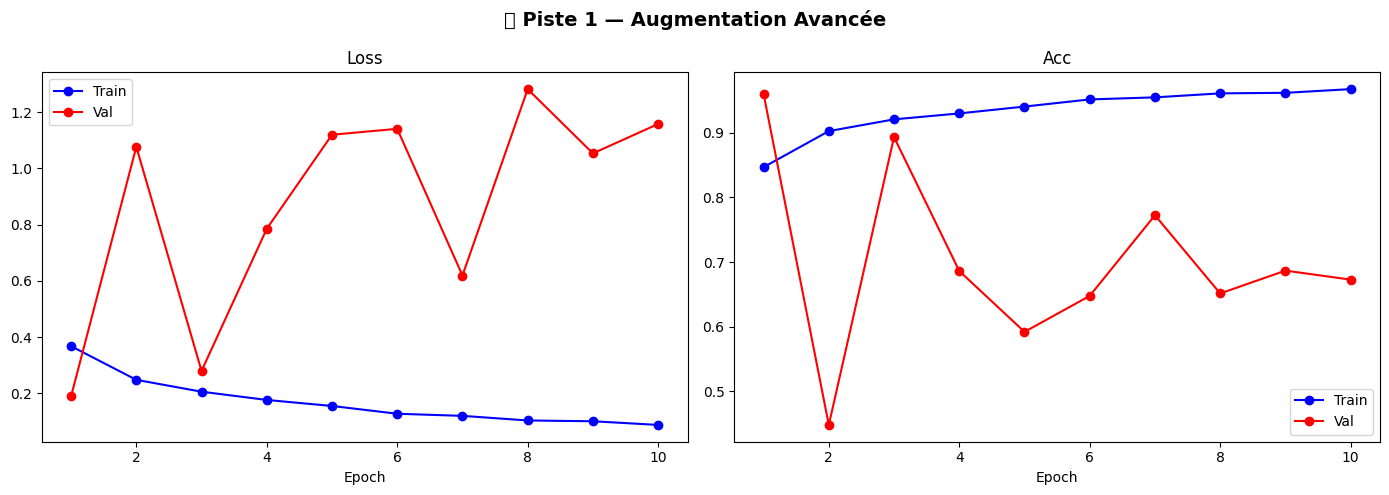

📊 Best Val Acc: 0.9604 (96.04%)


In [13]:
plot_history(history_p1, '🔵 Piste 1 — Augmentation Avancée')


# Hint 2 : Architecture 

In [14]:
import gc, os
os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")   # stack traces synchrones

torch.backends.cudnn.benchmark     = False
torch.backends.cudnn.deterministic = True

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from collections import Counter
import copy
import time
import matplotlib.pyplot as plt

# ============================================
# 1. CONFIGURATION DE BASE
# ============================================

# Chemins
BASE_PATH = "/kaggle/input/datasets/andrewmvd/leukemia-classification/C-NMC_Leukemia"
TRAIN_PATH = os.path.join(BASE_PATH, "training_data")
VAL_PATH = os.path.join(BASE_PATH, "validation_data")

# Paramètres
BATCH_SIZE = 128
NUM_EPOCHS = 10
SEED = 42

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"💻 Device: {device}")
print(f"🎮 GPUs disponibles: {num_gpus}")

# Classes
sample_fold = datasets.ImageFolder(os.path.join(TRAIN_PATH, "fold_0"))
class_names = sample_fold.classes
num_classes = len(class_names)
print(f"📊 Classes: {class_names}")
print(f"🎯 Nombre de classes: {num_classes}")

# ============================================
# 2. TRANSFORMATIONS PAR ARCHITECTURE
# ============================================

IMG_SIZES = {
    'efficientnet_b0': 224,
    'efficientnet_b2': 260,
    'densenet121': 224,
    'mobilenet_v3': 224
}

BATCH_SIZES = {
    'efficientnet_b0': 128,
    'efficientnet_b2': 64,
    'densenet121': 128,
    'mobilenet_v3': 128
}

def get_transforms(arch):
    """Retourne les transformations train/val pour une architecture donnée"""
    size = IMG_SIZES.get(arch, 224)
    
    train_transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

# ============================================
# 3. DATA LOADERS (TOUS LES FOLDS POUR TRAIN)
# ============================================

def get_loaders(arch):
    """Crée les DataLoaders avec tous les folds pour l'entraînement"""
    bs = BATCH_SIZES.get(arch, BATCH_SIZE)
    train_transform, val_transform = get_transforms(arch)
    
    # Charger tous les folds pour l'entraînement
    print(f"📁 Chargement des données pour {arch}...")
    train_folds = []
    for i in range(3):
        fold_path = os.path.join(TRAIN_PATH, f"fold_{i}")
        fold_dataset = datasets.ImageFolder(fold_path, transform=train_transform)
        train_folds.append(fold_dataset)
        print(f"   - Fold_{i}: {len(fold_dataset)} images")
    
    # Combiner les 3 folds
    train_dataset = ConcatDataset(train_folds)
    print(f"   - Total train: {len(train_dataset)} images")
    
    # Validation dataset
    val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transform)
    print(f"   - Validation: {len(val_dataset)} images")
    
    # DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=bs, shuffle=True,
        num_workers=4, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=bs, shuffle=False,
        num_workers=4, pin_memory=True
    )
    
    return train_loader, val_loader

# ============================================
# 4. CONSTRUCTION DES MODÈLES
# ============================================

def build_efficientnet_b0(num_classes=2):
    """EfficientNet-B0 avec tête personnalisée"""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )
    if num_gpus > 1:
        model = nn.DataParallel(model)
    return model.to(device)

def build_efficientnet_b2(num_classes=2):
    """EfficientNet-B2 avec tête personnalisée"""
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    # B2 avec channels_last pour éviter les problèmes mémoire
    model = model.to(memory_format=torch.channels_last)
    if num_gpus > 1:
        model = nn.DataParallel(model)
    return model.to(device)

def build_densenet121(num_classes=2):
    """DenseNet121 avec tête personnalisée"""
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    if num_gpus > 1:
        model = nn.DataParallel(model)
    return model.to(device)

def build_mobilenet_v3(num_classes=2):
    """MobileNet V3 Large avec tête personnalisée"""
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    in_features = model.classifier[3].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    if num_gpus > 1:
        model = nn.DataParallel(model)
    return model.to(device)

def build_model(arch, num_classes=2):
    """Factory function pour construire le modèle selon l'architecture"""
    architectures = {
        'efficientnet_b0': build_efficientnet_b0,
        'efficientnet_b2': build_efficientnet_b2,
        'densenet121': build_densenet121,
        'mobilenet_v3': build_mobilenet_v3
    }
    
    if arch not in architectures:
        raise ValueError(f"Architecture {arch} non supportée. Choix: {list(architectures.keys())}")
    
    model_builder = architectures[arch]
    model = model_builder(num_classes)
    
    # Afficher le nombre de paramètres
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 {arch}: {n_params:,} paramètres entraînables")
    
    return model


💻 Device: cuda
🎮 GPUs disponibles: 2
📊 Classes: ['all', 'hem']
🎯 Nombre de classes: 2


In [ ]:
# ✅ Libérer la VRAM avant de charger B2 (plus lourd que B0)
del model_p2
gc.collect()
torch.cuda.empty_cache()
print("VRAM libérée ✅")


📁 Chargement des données pour efficientnet_b0...
   - Fold_0: 3527 images
   - Fold_1: 3581 images
   - Fold_2: 3553 images
   - Total train: 10661 images
   - Validation: 1867 images
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


📊 efficientnet_b0: 4,664,446 paramètres entraînables
Epoch 1/10 [P2-efficientnet_b0]
  train Loss: 0.3964  Acc: 0.8322
  val   Loss: 0.2887  Acc: 0.9614

Epoch 2/10 [P2-efficientnet_b0]
  train Loss: 0.2874  Acc: 0.8804
  val   Loss: 0.1187  Acc: 0.9818

Epoch 3/10 [P2-efficientnet_b0]
  train Loss: 0.2417  Acc: 0.9003
  val   Loss: 0.2372  Acc: 0.9330

Epoch 4/10 [P2-efficientnet_b0]
  train Loss: 0.2121  Acc: 0.9144
  val   Loss: 1.1486  Acc: 0.4440

Epoch 5/10 [P2-efficientnet_b0]
  train Loss: 0.1905  Acc: 0.9212
  val   Loss: 1.1846  Acc: 0.4912

Epoch 6/10 [P2-efficientnet_b0]
  train Loss: 0.1739  Acc: 0.9285
  val   Loss: 0.2995  Acc: 0.8731

Epoch 7/10 [P2-efficientnet_b0]
  train Loss: 0.1633  Acc: 0.9321
  val   Loss: 0.5338  Acc: 0.7820

Epoch 8/10 [P2-efficientnet_b0]
  train Loss: 0.1542  Acc: 0.9373
  val   Loss: 0.6782  Acc: 0.7381

Epoch 9/10 [P2-efficientnet_b0]
  train Loss: 0.1507  Acc: 0.9386
  val   Loss: 0.4750  Acc: 0.8157

Epoch 10/10 [P2-efficientnet_b0]
  tra

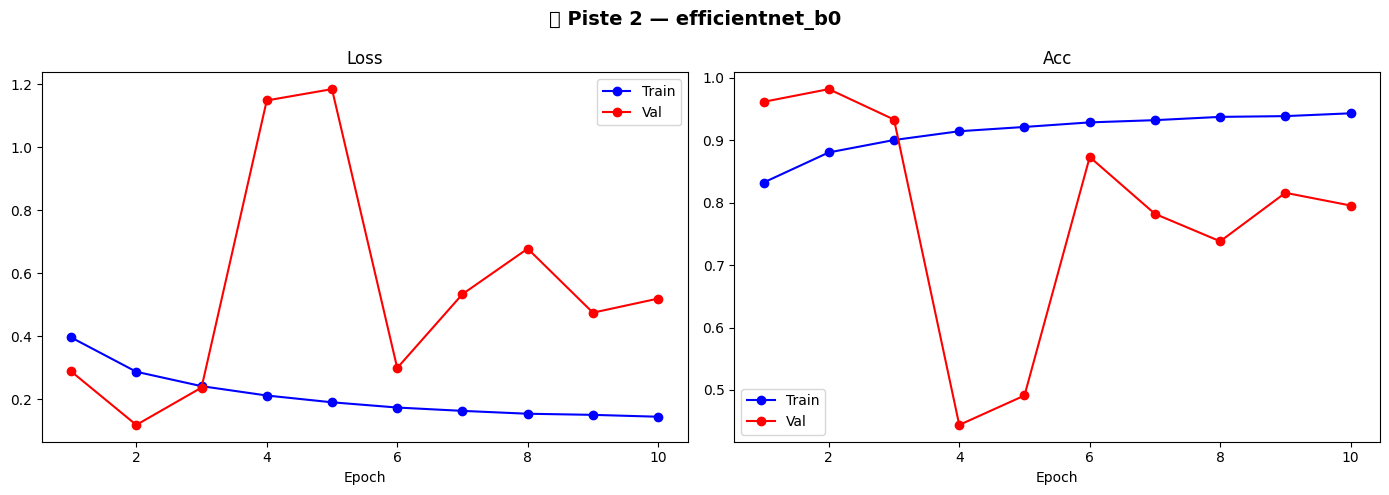

📊 Best Val Acc: 0.9818 (98.18%)


In [17]:
# ── 🔧 Run 1 : EfficientNet-B0 ─────────────────────────────────────────────
ARCH = 'efficientnet_b0'
train_loader_p2, val_loader_p2 = get_loaders(ARCH)  # ✅ Correct

model_p2 = build_model(ARCH)  # ✅ Correct (mais attention à num_classes)
criterion = nn.CrossEntropyLoss()
optimizer_p2 = optim.Adam(model_p2.parameters(), lr=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=NUM_EPOCHS)

model_p2, history_p2_b0 = train_model(
    model_p2, criterion, optimizer_p2,
    scheduler=scheduler_p2,
    train_loader=train_loader_p2,
    val_loader=val_loader_p2,
    label=f'P2-{ARCH}'
)
plot_history(history_p2_b0, f'🟠 Piste 2 — {ARCH}')
history_p2 = history_p2_b0

In [ ]:
#del model_p2
#torch.cuda.empty_cache()

In [ ]:
# import gc
#gc.collect()
#torch.cuda.empty_cache()


In [ ]:
ARCH     = 'densenet121'
model_p2 = build_model(ARCH)

optimizer_p2 = optim.Adam(model_p2.parameters(), lr=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=NUM_EPOCHS
)

model_p2, history_p2 = train_model(
    model_p2, criterion, optimizer_p2,
    scheduler=scheduler_p2,
    label=f'P2-{ARCH}'
)
plot_history(history_p2, f'🟠 Piste 2 — {ARCH}')

In [ ]:
# import gc
#del model_p2
#gc.collect()
#torch.cuda.empty_cache()

# Hint 3 : Scheduler

In [ ]:
model_p3     = build_baseline_model()
criterion    = nn.CrossEntropyLoss()
optimizer_p3 = optim.AdamW(model_p3.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_p3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p3, T_max=NUM_EPOCHS, eta_min=1e-6)

model_p3, history_p3 = train_model(
    model_p3, criterion, optimizer_p3, 
    scheduler=scheduler_p3, 
    label='P3-AdamW+Cosine'
)
plot_history(history_p3, '🟣 Piste 3 — AdamW + CosineAnnealing')

In [ ]:
#del model_p3
#gc.collect()
#torch.cuda.empty_cache()

# Hint 4 : Imbalance 

In [ ]:
# Poids classes
train_labels = [train_full.targets[i] for i in train_idx]
counts = Counter(train_labels)
total  = sum(counts.values())

wts    = torch.tensor(
    [total / (len(counts) * counts[i]) for i in range(len(class_names))],
    dtype=torch.float
).to(device)
crit_w = nn.CrossEntropyLoss(weight=wts)

# Sampler
s_wts   = torch.tensor([wts[l].item() for l in train_labels])
sampler = torch.utils.data.WeightedRandomSampler(s_wts, len(s_wts))

train_loader_bal = DataLoader(
    Subset(train_full, train_idx),  # ✅
    batch_size=BATCH_SIZE, 
    sampler=sampler, 
    num_workers=4, pin_memory=True
)

# Modèle
model_p4     = build_baseline_model()
optimizer_p4 = optim.Adam(model_p4.parameters(), lr=1e-4)  # ✅ séparé
scheduler_p4 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p4, T_max=NUM_EPOCHS)

model_p4, history_p4 = train_model(
    model_p4, crit_w, optimizer_p4,
    scheduler=scheduler_p4,
    train_loader=train_loader_bal,
    label='P4-Desequilibre'
)
plot_history(history_p4, '🔴 Piste 4 — Gestion du Déséquilibre')

# Matrice de confusion
model_p4.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model_p4(inputs.to(device))
        all_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
sns.heatmap(
    confusion_matrix(all_labels, all_preds), 
    annot=True, fmt='d',
    xticklabels=class_names, 
    yticklabels=class_names, 
    cmap='Blues'
)
plt.title('Matrice de Confusion — Piste 4')
plt.show()

# Hint 5 : Progressive fine-tuning

In [ ]:
# --- PHASE 1 : Backbone gelé ---
model_p5 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in model_p5.parameters(): 
    p.requires_grad = False

f = model_p5.fc.in_features
model_p5.fc = nn.Sequential(
    nn.Linear(f, 512), nn.BatchNorm1d(512), 
    nn.ReLU(), nn.Dropout(0.4), 
    nn.Linear(512, len(class_names))
)

if num_gpus > 1: model_p5 = nn.DataParallel(model_p5)  # ✅
model_p5 = model_p5.to(device)

opt1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_p5.parameters()), 
    lr=1e-3
)
model_p5, hist1 = train_model(
    model_p5, criterion, opt1, 
    num_epochs=5, label='P5-Phase1'
)

# --- PHASE 2 : Dégel layer3 + layer4 ---
base = model_p5.module if num_gpus > 1 else model_p5  # ✅

for name, p in base.named_parameters():
    if any(l in name for l in ['layer4', 'layer3', 'fc']): 
        p.requires_grad = True

opt2 = optim.Adam([
    {'params': base.layer3.parameters(), 'lr': 1e-5},  # ✅
    {'params': base.layer4.parameters(), 'lr': 5e-5},
    {'params': base.fc.parameters(),     'lr': 1e-4},
])
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=5, eta_min=1e-7)

model_p5, hist2 = train_model(
    model_p5, criterion, opt2, 
    scheduler=sch2, num_epochs=5, label='P5-Phase2'
)

hist_p5 = {k: hist1[k] + hist2[k] for k in hist1}
plot_history(hist_p5, '🟡 Piste 5 — Fine-Tuning Progressif')

# Combination + Final Dashboard

In [ ]:
# ========================================
# 🏆 COMBINAISON GAGNANTE
# ResNet50 + AdamW + Cosine + Loss pondérée
# (basé sur tes meilleurs résultats)
# ========================================

# Poids classes depuis p4
train_labels_comb = [train_full.targets[i] for i in train_idx]
counts_comb = Counter(train_labels_comb)
total_comb  = sum(counts_comb.values())
wts_comb    = torch.tensor(
    [total_comb / (len(counts_comb) * counts_comb[i]) for i in range(len(class_names))],
    dtype=torch.float
).to(device)
crit_comb = nn.CrossEntropyLoss(weight=wts_comb)

model_best     = build_baseline_model()
optimizer_best = optim.AdamW(model_best.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_best = optim.lr_scheduler.CosineAnnealingLR(optimizer_best, T_max=NUM_EPOCHS, eta_min=1e-6)

model_best, history_best = train_model(
    model_best, crit_comb, optimizer_best,
    scheduler=scheduler_best,
    label='Best-Combo'
)
plot_history(history_best, '🏆 Combinaison Gagnante')

# ========================================
# 📊 COMPARAISON FINALE
# ========================================
all_histories = {
    '🟢 Baseline' : history_baseline,
    '🔵 P1-Augment': history_p1,
    '🟠 P2-DenseNet': history_p2,
    '🟣 P3-AdamW'  : history_p3,
    '🔴 P4-Balance' : history_p4,
    '🟡 P5-Finetune': hist_p5,
    '🏆 Best-Combo' : history_best,
}

results = {}
for name, hist in all_histories.items():
    try:
        results[name] = max(hist['val_acc'])  # ✅ pas de eval()
    except:
        pass

print('=' * 50)
for rank, (name, acc) in enumerate(
    sorted(results.items(), key=lambda x: -x[1]), 1
):
    medal = ['🥇', '🥈', '🥉'][rank-1] if rank <= 3 else '  '
    print(f'  {medal} #{rank}  {name:25s}: {acc*100:.2f}%')
print('=' * 50)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
values = list(results.values())
colors = ['#2ecc71' if v == max(values) else '#3498db' for v in values]
bars   = ax.barh(names, values, color=colors, height=0.6)
for bar, val in zip(bars, values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontweight='bold')
ax.set_xlabel('Val Accuracy')
ax.set_xlim(0, 1)
ax.set_title('📊 Classement Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
plot_history(history_best, '🏆 Combinaison Gagnante')

# ========================================
# 📊 COMPARAISON FINALE
# ========================================
all_histories = {
    '🟢 Baseline' : history_baseline,
    '🔵 P1-Augment': history_p1,
    '🟠 P2-DenseNet': history_p2,
    '🟣 P3-AdamW'  : history_p3,
    '🔴 P4-Balance' : history_p4,
    '🟡 P5-Finetune': hist_p5,
    '🏆 Best-Combo' : history_best,
}

results = {}
for name, hist in all_histories.items():
    try:
        results[name] = max(hist['val_acc'])  # ✅ pas de eval()
    except:
        pass

print('=' * 50)
for rank, (name, acc) in enumerate(
    sorted(results.items(), key=lambda x: -x[1]), 1
):
    medal = ['🥇', '🥈', '🥉'][rank-1] if rank <= 3 else '  '
    print(f'  {medal} #{rank}  {name:25s}: {acc*100:.2f}%')
print('=' * 50)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
values = list(results.values())
colors = ['#2ecc71' if v == max(values) else '#3498db' for v in values]
bars   = ax.barh(names, values, color=colors, height=0.6)
for bar, val in zip(bars, values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontweight='bold')
ax.set_xlabel('Val Accuracy')
ax.set_xlim(0, 1)
ax.set_title('📊 Classement Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

model_final    = build_baseline_model()
criterion_final = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_final = optim.AdamW(model_final.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_final = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final, T_max=30, eta_min=1e-6
)

model_final, history_final = train_model(
    model_final, criterion_final, optimizer_final,
    scheduler=scheduler_final,
    num_epochs=30,  # 👈 explicite
    label='Final-30epochs'
)
plot_history(history_final, '🏆 Final — ResNet50 30 epochs')